# Modelo ARIMA para previsão de visualizações do Portal TRT-18

A base utilizada contém apenas duas colunas:

- `Data`: data da observação;
- `Visualizações`: número diário de visualizações de página.

## 1. Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para manipulação dos dados, visualização gráfica, ajuste do modelo ARIMA e cálculo das métricas de desempenho.

Também são importadas funções específicas para o teste de estacionariedade da série temporal e para a construção do modelo ARIMA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

## 2. Geração da base específica para o ARIMA

A base original tratada contém diferentes variáveis relacionadas ao tráfego do portal, como usuários ativos, sessões, visualizações e variáveis de calendário.

Para o modelo ARIMA puro, será utilizada uma estrutura contendo apenas a data e a variável-alvo `Visualizações`. Essa escolha ocorre porque o ARIMA modela a série com base nos próprios valores históricos da variável analisada, sem utilizar variáveis explicativas externas.


In [2]:
# Carregar a base tratada geral
df = pd.read_csv("../dados/trafego_tratado.csv")

# Converter a coluna de data
df["Data"] = pd.to_datetime(df["Data"])

# Ordenar cronologicamente
df = df.sort_values("Data")

# Manter apenas a data e a variável-alvo
df_arima = df[["Data", "Visualizações"]].copy()

# Salvar a base específica do ARIMA
df_arima.to_csv("../dados/trafego_arima_visualizacoes.csv", index=False)

# Visualizar
df_arima.head()

,Data,Visualizações
0,2023-07-01,5566
1,2023-07-02,5498
2,2023-07-03,46786
3,2023-07-04,44984
4,2023-07-05,43559


## 3. Preparação da série temporal

Para aplicação do modelo ARIMA, a coluna `Data` será definida como índice temporal. Em seguida, será estabelecida a frequência diária da série.


In [3]:
serie = df_arima.copy()

serie = serie.set_index("Data")
serie = serie.asfreq("D")

serie.head()

,Visualizações
Data,
2023-07-01,5566
2023-07-02,5498
2023-07-03,46786
2023-07-04,44984
2023-07-05,43559


## 4. Verificação de valores ausentes

Após definir a frequência diária da série, é necessário verificar se existem datas sem registro ou valores ausentes na coluna `Visualizações`.

Essa verificação é importante porque o modelo ARIMA exige uma série temporal contínua e regular.

In [4]:
serie.isna().sum()

Visualizações    0
dtype: int64

## 5. Visualização inicial da série temporal

Antes do ajuste do modelo ARIMA, será realizada uma visualização da série histórica de visualizações.

Essa análise permite observar o comportamento geral dos acessos ao longo do tempo, incluindo possíveis tendências, sazonalidades, quedas em fins de semana, feriados, recessos e períodos atípicos.

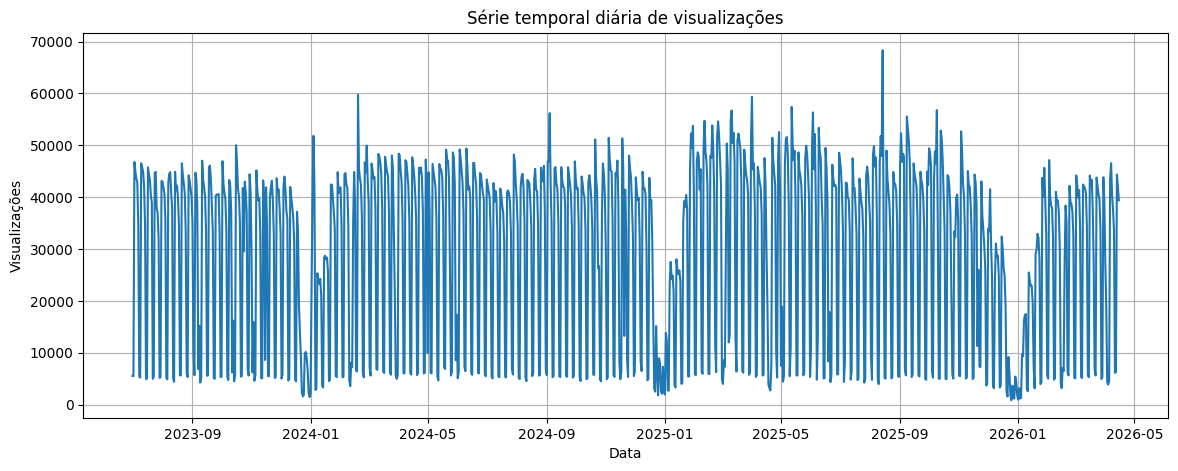

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(serie.index, serie["Visualizações"])

plt.title("Série temporal diária de visualizações")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.grid(True)

plt.show()

## 6. Divisão entre treino e teste

A série temporal será dividida em conjuntos de treino e teste de forma sequencial, preservando a ordem cronológica dos dados.

Essa abordagem é necessária porque, em séries temporais, os dados futuros não devem ser usados para treinar o modelo. Neste experimento, serão utilizados 80% dos dados para treinamento e 20% para teste.

In [6]:
tamanho_treino = int(len(serie) * 0.8)

treino = serie.iloc[:tamanho_treino]
teste = serie.iloc[tamanho_treino:]

print("Total de observações:", len(serie))
print("Treino:", len(treino))
print("Teste:", len(teste))

print("\nPeríodo de treino:")
print(treino.index.min(), "até", treino.index.max())

print("\nPeríodo de teste:")
print(teste.index.min(), "até", teste.index.max())

Total de observações: 1020
Treino: 816
Teste: 204

Período de treino:
2023-07-01 00:00:00 até 2025-09-23 00:00:00

Período de teste:
2025-09-24 00:00:00 até 2026-04-15 00:00:00


## 7. Visualização da divisão entre treino e teste

O gráfico a seguir apresenta a separação entre o conjunto de treino e o conjunto de teste.


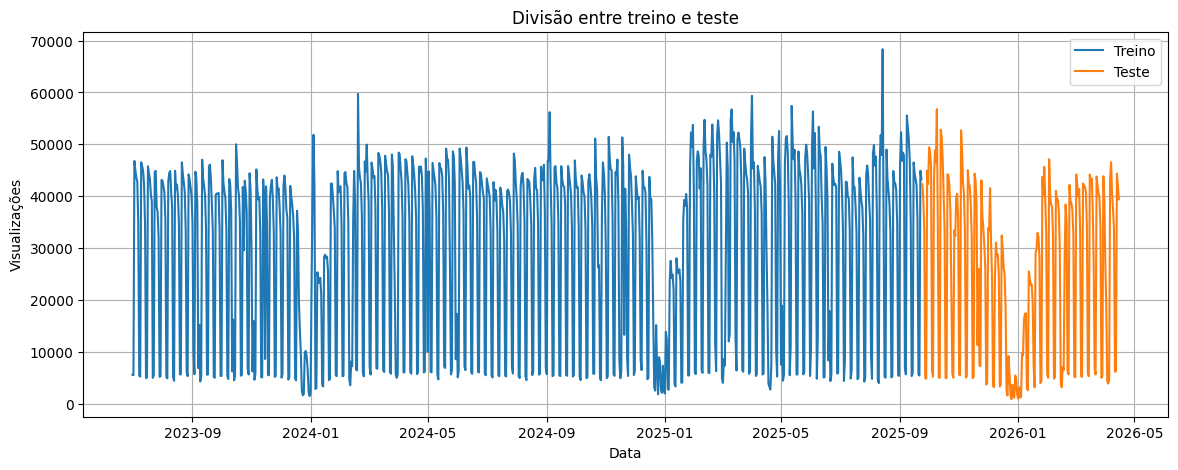

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(treino.index, treino["Visualizações"], label="Treino")
plt.plot(teste.index, teste["Visualizações"], label="Teste")

plt.title("Divisão entre treino e teste")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.grid(True)

plt.show()

## 8. Teste de estacionariedade

O modelo ARIMA pressupõe que a série seja estacionária ou que possa se tornar estacionária por meio de diferenciação.
Para verificar essa característica, será aplicado o teste de Dickey-Fuller aumentado sobre a série de treino.

De forma simplificada:

- p-valor menor ou igual a 0,05 indica evidência de estacionariedade;
- p-valor maior que 0,05 indica que a série provavelmente não é estacionária.


In [8]:
def teste_adf(serie_temporal):
    resultado = adfuller(serie_temporal.dropna())
    
    print("Estatística ADF:", resultado[0])
    print("p-valor:", resultado[1])
    print("Valores críticos:")
    
    for chave, valor in resultado[4].items():
        print(f"   {chave}: {valor}")

    if resultado[1] <= 0.05:
        print("\nConclusão: a série apresenta evidência de estacionariedade.")
    else:
        print("\nConclusão: a série NÃO apresenta evidência suficiente de estacionariedade.")

        

In [9]:
teste_adf(treino["Visualizações"])

Estatística ADF: -3.98247304605995
p-valor: 0.0015051199967124934
Valores críticos:
   1%: -3.4386126789104074
   5%: -2.865186972298872
   10%: -2.5687119871327146

Conclusão: a série apresenta evidência de estacionariedade.


## 9. Definição do grau de diferenciação

O teste de Dickey-Fuller aumentado apresentou p-valor inferior a 0,05, indicando evidência de estacionariedade na série de treino.

Dessa forma, não será aplicada diferenciação inicial à série, sendo adotado o parâmetro `d = 0` no modelo ARIMA.

Com isso, a próxima etapa consiste em testar diferentes combinações dos parâmetros `p` e `q`, escolhendo a configuração com menor valor de AIC.

In [10]:
d = 0

resultados = []

p_values = range(0, 8)
q_values = range(0, 8)

for p in p_values:
    for q in q_values:
        try:
            modelo = ARIMA(
                treino["Visualizações"],
                order=(p, d, q)
            )
            
            modelo_ajustado = modelo.fit()
            
            resultados.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": modelo_ajustado.aic
            })
            
        except Exception as erro:
            continue

resultados_arima = pd.DataFrame(resultados)
resultados_arima = resultados_arima.sort_values("AIC")

resultados_arima.head(10)

,p,d,q,AIC
63,7,0,7,16798.823836
62,7,0,6,16824.274528
61,7,0,5,16949.328580
60,7,0,4,17003.642600
59,7,0,3,17011.326289
58,7,0,2,17031.232356
57,7,0,1,17047.817683
55,6,0,7,17076.694346
54,6,0,6,17080.210438
53,6,0,5,17105.256170


## 10. Seleção do melhor modelo ARIMA

A busca pelos parâmetros do ARIMA indicou como melhor combinação o modelo com menor valor de AIC.

O critério AIC penaliza modelos excessivamente complexos, mas favorece aqueles que apresentam melhor ajuste estatístico aos dados de treino.

Com base nesse critério, será selecionada automaticamente a combinação `(p, d, q)` com menor AIC para ajuste do modelo final de treino.

In [11]:
melhor_modelo = resultados_arima.iloc[0]

p = int(melhor_modelo["p"])
d = int(melhor_modelo["d"])
q = int(melhor_modelo["q"])

print("Melhor modelo ARIMA encontrado:")
print(f"ARIMA({p}, {d}, {q})")
print("AIC:", melhor_modelo["AIC"])

Melhor modelo ARIMA encontrado:
ARIMA(7, 0, 7)
AIC: 16798.82383629511


## 11. Ajuste do modelo ARIMA

Após a seleção dos parâmetros `(p, d, q)`, o modelo ARIMA será ajustado ao conjunto de treino.

Nesta etapa, o modelo aprende os padrões temporais existentes na série histórica de visualizações, utilizando apenas os dados anteriores ao período de teste.

In [12]:
modelo_arima = ARIMA(
    treino["Visualizações"],
    order=(p, d, q)
)

modelo_arima_ajustado = modelo_arima.fit()

print(modelo_arima_ajustado.summary())

                               SARIMAX Results                                
Dep. Variable:          Visualizações   No. Observations:                  816
Model:                 ARIMA(7, 0, 7)   Log Likelihood               -8383.412
Date:                Wed, 13 May 2026   AIC                          16798.824
Time:                        22:32:18   BIC                          16874.094
Sample:                    07-01-2023   HQIC                         16827.712
                         - 09-23-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.981e+04   2417.574     12.329      0.000    2.51e+04    3.45e+04
ar.L1         -0.0820      0.025     -3.325      0.001      -0.130      -0.034
ar.L2         -0.0750      0.023     -3.253      0.0

In [ ]:
## 12. Previsão no conjunto de teste

Após o ajuste do modelo ARIMA ao conjunto de treino, será realizada a previsão para o mesmo horizonte temporal do conjunto de teste.

Essa etapa permite comparar os valores previstos pelo modelo com os valores reais observados no período reservado para avaliação.

In [13]:
previsao = modelo_arima_ajustado.get_forecast(steps=len(teste))

y_pred = previsao.predicted_mean
intervalo = previsao.conf_int()

y_pred.index = teste.index
intervalo.index = teste.index

df_previsao = pd.DataFrame({
    "Data": teste.index,
    "Real": teste["Visualizações"].values,
    "Previsto": y_pred.values,
    "Limite_inferior": intervalo.iloc[:, 0].values,
    "Limite_superior": intervalo.iloc[:, 1].values
})

df_previsao.head()

,Data,Real,Previsto,Limite_inferior,Limite_superior
0,2025-09-24,42297,41396.553969,26783.226928,56009.881009
1,2025-09-25,39531,41677.084795,24983.321653,58370.847937
2,2025-09-26,33420,33295.672915,15938.890604,50652.455226
3,2025-09-27,4954,3911.886844,-13857.739840,21681.513527
4,2025-09-28,4796,4151.546858,-13956.714779,22259.808496


## 13. Avaliação do desempenho do modelo

O desempenho do modelo ARIMA será avaliado comparando os valores reais observados no conjunto de teste com os valores previstos pelo modelo.

Serão utilizadas as seguintes métricas:

- MAE: erro absoluto médio;
- RMSE: raiz do erro quadrático médio;
- MAPE: erro percentual absoluto médio;
- R²: coeficiente de determinação.

Essas métricas permitirão comparar o desempenho do ARIMA com os demais modelos utilizados no estudo.

In [14]:
def calcular_mape(y_real, y_previsto):
    y_real = np.array(y_real)
    y_previsto = np.array(y_previsto)
    
    # Evita divisão por zero, caso exista algum valor real igual a zero
    mascara = y_real != 0
    
    return np.mean(np.abs((y_real[mascara] - y_previsto[mascara]) / y_real[mascara])) * 100


mae = mean_absolute_error(df_previsao["Real"], df_previsao["Previsto"])

rmse = np.sqrt(
    mean_squared_error(df_previsao["Real"], df_previsao["Previsto"])
)

mape = calcular_mape(df_previsao["Real"], df_previsao["Previsto"])

r2 = r2_score(df_previsao["Real"], df_previsao["Previsto"])


metricas_arima = pd.DataFrame({
    "Modelo": ["ARIMA"],
    "Ordem": [f"({p}, {d}, {q})"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE (%)": [mape],
    "R²": [r2]
})

metricas_arima

,Modelo,Ordem,MAE,RMSE,MAPE (%),R²
0,ARIMA,"(7, 0, 7)",7146.328605,11357.860865,139.531925,0.542901


## 14. Comparação entre valores reais e previstos

O gráfico a seguir compara os valores reais observados no conjunto de teste com os valores previstos pelo modelo ARIMA.

Essa visualização permite avaliar se o modelo conseguiu acompanhar os principais padrões da série, especialmente as oscilações semanais e os períodos de queda no volume de visualizações.

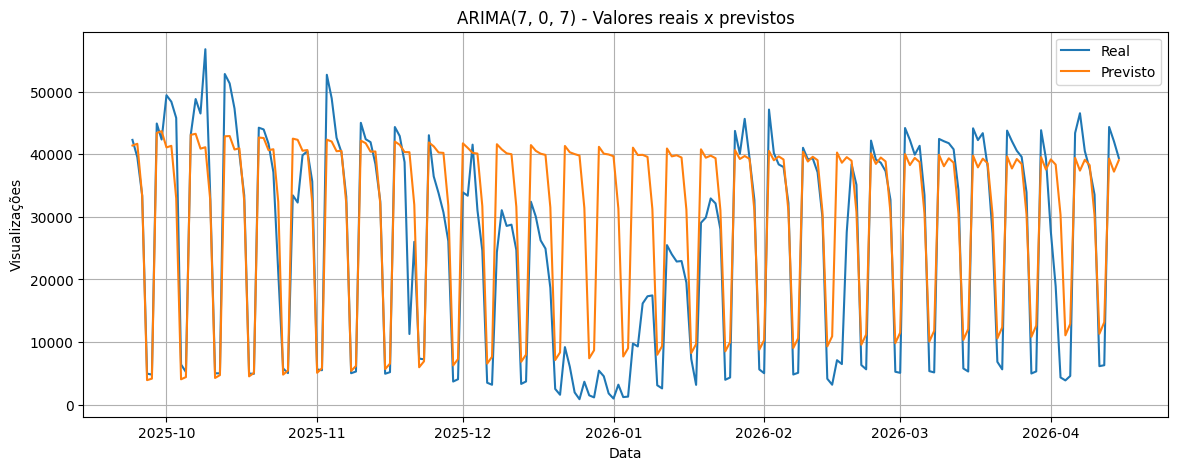

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(df_previsao["Data"], df_previsao["Real"], label="Real")
plt.plot(df_previsao["Data"], df_previsao["Previsto"], label="Previsto")

plt.title(f"ARIMA{p, d, q} - Valores reais x previstos")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.grid(True)

plt.show()

## 15. Salvamento dos resultados do ARIMA

As previsões geradas para o conjunto de teste e as métricas de desempenho do modelo serão salvas em arquivos CSV.

Esses arquivos serão utilizados posteriormente na etapa de comparação entre os modelos aplicados no estudo.

In [16]:
df_previsao.to_csv("../dados/previsao_arima_visualizacoes.csv", index=False)
metricas_arima.to_csv("../dados/metricas_arima.csv", index=False)

print("Arquivos salvos com sucesso:")
print("- previsao_arima_visualizacoes.csv")
print("- metricas_arima.csv")

Arquivos salvos com sucesso:
- previsao_arima_visualizacoes.csv
- metricas_arima.csv


In [ ]:
## 16. Síntese dos resultados do ARIMA

O modelo ARIMA puro foi aplicado à série temporal diária de visualizações do portal, utilizando apenas os valores históricos da própria variável-alvo.

A configuração selecionada foi ARIMA(7, 0, 7), escolhida com base no menor valor de AIC entre as combinações testadas. O modelo conseguiu capturar parte da sazonalidade semanal da série, mas apresentou dificuldade nos períodos atípicos, especialmente durante o recesso de fim de ano.

O desempenho no conjunto de teste foi:

- MAE: aproximadamente 7.146 visualizações;
- RMSE: aproximadamente 11.358 visualizações;
- MAPE: aproximadamente 139,53%;
- R²: aproximadamente 0,543.

O MAPE elevado deve ser interpretado com cautela, pois a série possui dias com valores muito baixos, principalmente em finais de semana, feriados e recessos. Nessas situações, erros absolutos moderados podem gerar erros percentuais muito altos.

Assim, o ARIMA será mantido como modelo estatístico de referência para comparação com os demais modelos do estudo.